# NB_06_queued_inference_demo - Queued Inference Demo - E2E vs Composed

**Purpose.** Replay a recorded scenario through both models (E2E ResNet-18 -> BDU-GRU and Composed perception -> BDU-GRU) frame-by-frame and overlay their predictions on the ground-truth risk curve.

**Inputs.** a dataset.jsonl under a scenario folder, plus the corresponding E2E and composed checkpoints.

**Outputs.** per-frame predictions, MSE table, interactive matplotlib plot with model selector; Town05 / Town10 multi-scenario overlays.

**How to run.** Set the scenario name and checkpoint paths in the Configuration section, then run top-to-bottom. The Town10 overlay loads composed checkpoints on demand.

**Position in the workflow.** Offline counterpart to NB_07 (latency benchmark). Both follow NB_04 training.


In [15]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from ultralytics import YOLO

from MIREIA.config import Config
from MIREIA.data_collection.dataset_utils import load_jsonl_records, resolve_image_path
from MIREIA.perception import (
    DepthAnythingV2Estimator,
    FeatureIntegrator,
    QueuedComposedBDUGRURiskInference,
    QueuedE2ERiskInference,
    create_environment_classifier_predictor,
    load_road_segmentation_model,
)

## Configuration

In [16]:
source_jsonl_name = "dataset.jsonl"
dataset_index = 72 #74          # Select dataset/scenario by index
start_frame = 0
num_frames_to_plot = 3500

# "e2e", "composed", or "both"
model_selection = "both"
selected_models = model_selection.strip().lower()
if selected_models not in {"e2e", "composed", "both"}:
    raise ValueError("model_selection must be one of: 'e2e', 'composed', 'both'")
run_e2e = selected_models in {"e2e", "both"}
run_composed = selected_models in {"composed", "both"}

## Dataset Discovery + Frame Loading

In [17]:
from MIREIA.config import Config
from MIREIA.data_collection.dataset_utils import (
    load_jsonl_records,
    normalize_crop_bbox_xyxy,
    resolve_image_path,
)
from pathlib import Path

scenarios_root = Path(Config.PATH_TO_SCENARIOS)
scenario_dirs = [
    p for p in sorted(scenarios_root.iterdir())
    if p.is_dir() and p.name not in {"videos", "__pycache__"} and (p / source_jsonl_name).is_file()
]

if not scenario_dirs:
    raise RuntimeError(f"No scenarios with {source_jsonl_name} found under {scenarios_root}")

print("Available datasets (select by index):")
for i, d in enumerate(scenario_dirs):
    print(f"[{i:02d}] {d.name}")

if not (0 <= dataset_index < len(scenario_dirs)):
    raise ValueError(f"dataset_index={dataset_index} out of range [0, {len(scenario_dirs) - 1}]")

selected_scenario_dir = scenario_dirs[dataset_index]
records = load_jsonl_records(str(selected_scenario_dir / source_jsonl_name))
if not records:
    raise RuntimeError(f"No records found in {selected_scenario_dir / source_jsonl_name}")

end_frame = min(len(records), start_frame + int(num_frames_to_plot))
selected_records = records[start_frame:end_frame]

frame_paths, frame_ids, real_risks = [], [], []
for rec in selected_records:
    rel_image = str(rec.get("rgb_image_path", "")).strip()
    if not rel_image:
        continue
    full_path = resolve_image_path(str(selected_scenario_dir), rel_image, normalize_paths=True)
    if not os.path.isfile(full_path):
        continue
    frame_paths.append(full_path)
    frame_ids.append(int(rec.get("frame_id", len(frame_ids))))
    real_risks.append(float(rec.get("ground_truth_risk", 0.0)))

if not frame_paths:
    raise RuntimeError("No valid image paths found.")

# Composed-model features are computed on a dashboard-cropped image. Force the
# same fixed crop the trial batch runner (NB_13) uses, [0, 0, 512, 305], so this
# notebook's composed inference matches the trial pipeline exactly. (The labeled
# scenarios store a per-scenario crop_bbox_xyxy, but we deliberately override it
# here to keep NB_06 and NB_13 consistent.)
selected_crop_bbox_xyxy = [0, 0, 512, 305]

print(f"\nSelected: {selected_scenario_dir.name}")
print(f"Usable frames: {len(frame_paths)}  |  Model selection: {selected_models}")
print(f"Composed crop bbox (xyxy): {selected_crop_bbox_xyxy}")

Available datasets (select by index):
[00] 01A_ClearNoon_Town01_HighVol
[01] 01B_ClearNoon_Town01_LowVol
[02] 01C_ClearNoon_Town02_HighVol
[03] 01D_ClearNoon_Town02_LowVol
[04] 02A_CloudyNoon_Town03_HighVol
[05] 02B_CloudyNoon_Town03_LowVol
[06] 02C_CloudyNoon_Town03_HighVol
[07] 02D_CloudyNoon_Town04_LowVol
[08] 03A_WetNoon_Town04_HighVol
[09] 03B_WetNoon_Town04_LowVol
[10] 03C_WetNoon_Town03_HighVol
[11] 03D_WetNoon_Town04_LowVol
[12] 04A_WetCloudyNoon_Town01_HighVol
[13] 04B_WetCloudyNoon_Town01_LowVol
[14] 04C_WetCloudyNoon_Town02_HighVol
[15] 04D_WetCloudyNoon_Town02_LowVol
[16] 05A_SoftRainNoon_Town03_HighVol
[17] 05B_SoftRainNoon_Town03_LowVol
[18] 05C_SoftRainNoon_Town01_HighVol
[19] 05D_SoftRainNoon_Town02_LowVol
[20] 06A_MidRainyNoon_Town04_HighVol
[21] 06B_MidRainyNoon_Town04_LowVol
[22] 06C_MidRainyNoon_Town03_HighVol
[23] 06D_MidRainyNoon_Town04_LowVol
[24] 07A_HardRainNoon_Town01_HighVol
[25] 07B_HardRainNoon_Town01_LowVol
[26] 07C_HardRainNoon_Town02_HighVol
[27] 07D_Har

## Model Loading

### Checkpoint Paths

In [18]:
device_name = "cuda" if torch.cuda.is_available() else "cpu"

MODEL_PATHS = {
    "yolo":     Path(Config.PATH_TO_MODELS) / "yolo11s.pt",
    "depth":    Path(Config.PATH_TO_MODELS) / "depth_anything_v2_vits.pth",
    "climate":  Path(Config.PATH_TO_MODELS) / "environment_multitask_checkpoint.pt",
    "road_seg": Path(Config.PATH_TO_MODELS) / "road_segmentation_multitask_checkpoint.pt",
}

e2e_checkpoint_paths = {
    #"e2e_latest": Path(Config.PATH_TO_MODELS) / "e2e_risk_checkpoint.pt",
    "e2e_1epoch": Path(Config.PATH_TO_MODELS) / "e2e_risk_checkpoint_1full_epoch.pt",
}

composed_checkpoint_paths = {
    "bdu_gru_search_02": Path(Config.PATH_TO_MODELS) / "bdu_gru_search_02.pt",  # no-skip model (matches NB_13)
}

other_bdu_gru = ["bdu_gru_run" + f"{i:02d}" for i in [2, 4]]
print("Names: " + ", ".join(other_bdu_gru))

composed_checkpoint_paths.update({name: Path(Config.PATH_TO_MODELS) / f"{name}.pt" for name in other_bdu_gru})
print("Composed checkpoint paths:")
for name, path in composed_checkpoint_paths.items():
    print(f"  {name}: {path}")

# Validation
required = {}
if run_e2e:
    required.update({f"e2e_{k}": v for k, v in e2e_checkpoint_paths.items()})
if run_composed:
    required.update({"yolo": MODEL_PATHS["yolo"], "depth": MODEL_PATHS["depth"]})
    required.update({f"{k}_ckpt": v for k, v in composed_checkpoint_paths.items()})

missing = [f"{k}: {v}" for k, v in required.items() if not Path(v).is_file()]
if missing:
    raise FileNotFoundError("Missing model files:\n" + "\n".join(missing))

print(f"Device: {device_name}")

Names: bdu_gru_run02, bdu_gru_run04
Composed checkpoint paths:
  bdu_gru_search_02: t:\TFG\MIREIA\models\bdu_gru_search_02.pt
  bdu_gru_run02: t:\TFG\MIREIA\models\bdu_gru_run02.pt
  bdu_gru_run04: t:\TFG\MIREIA\models\bdu_gru_run04.pt
Device: cuda


### Load E2E Predictors

In [19]:
e2e_predictors = {}
if run_e2e:
    for name, ckpt_path in e2e_checkpoint_paths.items():
        e2e_predictors[name] = QueuedE2ERiskInference.from_checkpoint(
            checkpoint_path=str(ckpt_path),
            device=device_name,
        )
        print(f"Loaded E2E: {name}")

e2e_predictor = next(iter(e2e_predictors.values())) if e2e_predictors else None

Loaded E2E: e2e_1epoch


### Load Composed Predictors

In [20]:
composed_predictors = {}
yolo_model = depth_estimator = environment_predictor = road_segmentation = None

if run_composed:
    yolo_model = YOLO(str(MODEL_PATHS["yolo"]))
    depth_estimator = DepthAnythingV2Estimator(
        checkpoint_path=MODEL_PATHS["depth"],
        encoder="vits",
        device=device_name,
    )
    environment_predictor = (
        create_environment_classifier_predictor(
            checkpoint_path=str(MODEL_PATHS["climate"]), device=device_name
        ) if MODEL_PATHS["climate"].is_file() else None
    )
    road_segmentation = (
        load_road_segmentation_model(checkpoint_path=str(MODEL_PATHS["road_seg"]), device=device_name)
        if MODEL_PATHS["road_seg"].is_file() else None
    )

    for name, checkpoint_path in composed_checkpoint_paths.items():
        composed_predictors[name] = QueuedComposedBDUGRURiskInference.from_checkpoint(
            checkpoint_path=str(checkpoint_path),
            feature_integrator=FeatureIntegrator(),
            yolo_model=yolo_model,
            depth_estimator=depth_estimator,
            environment_predictor=environment_predictor,
            road_segmentation=road_segmentation,
            device=device_name,
            manual_crop_bbox=selected_crop_bbox_xyxy,  # match the dashboard crop used at labeling
        )
        print(f"Loaded Composed: {name}")

print("Environment predictor loaded:", environment_predictor is not None)
print("Road segmentation loaded:", road_segmentation is not None)

Loaded Composed: bdu_gru_search_02
Loaded Composed: bdu_gru_run02
Loaded Composed: bdu_gru_run04
Environment predictor loaded: True
Road segmentation loaded: True


## Inference

### Helper

In [21]:
from time import perf_counter

used_frame_ids = [int(fid) for fid in frame_ids]
real_vals = [float(r) for r in real_risks]
total_frames = len(frame_paths)


def _run_model_inference(model_name, predictor):
    predictor.reset_queue()
    preds = []
    t_start = perf_counter()

    for done, (frame_path, frame_id) in enumerate(zip(frame_paths, used_frame_ids), start=1):
        out = predictor.add_image_path(frame_path)
        preds.append(float(out.latest_risk) if out.ready and out.latest_risk is not None else np.nan)

        if done % 10 == 0 or done == total_frames:
            elapsed_s = perf_counter() - t_start
            fps = done / max(elapsed_s, 1e-9)
            eta_s = (total_frames - done) / max(fps, 1e-9)
            print(f"[{model_name}] [{done}/{total_frames}] fps={fps:.1f} eta={eta_s:.1f}s")

    elapsed_total = perf_counter() - t_start
    fps_total = total_frames / max(elapsed_total, 1e-9)
    print(f"[{model_name}] done in {elapsed_total:.1f}s ({fps_total:.1f} FPS).")
    return preds, elapsed_total, fps_total

### Run E2E

In [22]:
e2e_preds_by_model, e2e_elapsed_by_model, e2e_fps_by_model = {}, {}, {}

if run_e2e:
    print("Running E2E inference...")
    for ckpt_name, predictor in e2e_predictors.items():
        preds, elapsed_s, fps = _run_model_inference(f"E2E:{ckpt_name}", predictor)
        e2e_preds_by_model[ckpt_name] = preds
        e2e_elapsed_by_model[ckpt_name] = elapsed_s
        e2e_fps_by_model[ckpt_name] = fps

# Backward-compat alias
_e2e_default_key = next(iter(e2e_preds_by_model)) if e2e_preds_by_model else None
e2e_preds = e2e_preds_by_model[_e2e_default_key] if _e2e_default_key else [np.nan] * total_frames
e2e_fps = e2e_fps_by_model[_e2e_default_key] if _e2e_default_key else float("nan")

Running E2E inference...
[E2E:e2e_1epoch] [10/3500] fps=37.9 eta=92.1s
[E2E:e2e_1epoch] [20/3500] fps=36.8 eta=94.7s
[E2E:e2e_1epoch] [30/3500] fps=35.5 eta=97.6s
[E2E:e2e_1epoch] [40/3500] fps=35.0 eta=98.8s
[E2E:e2e_1epoch] [50/3500] fps=34.6 eta=99.6s
[E2E:e2e_1epoch] [60/3500] fps=34.5 eta=99.7s
[E2E:e2e_1epoch] [70/3500] fps=34.5 eta=99.5s
[E2E:e2e_1epoch] [80/3500] fps=34.4 eta=99.3s
[E2E:e2e_1epoch] [90/3500] fps=34.5 eta=98.8s
[E2E:e2e_1epoch] [100/3500] fps=34.6 eta=98.2s
[E2E:e2e_1epoch] [110/3500] fps=34.6 eta=97.9s
[E2E:e2e_1epoch] [120/3500] fps=34.7 eta=97.5s
[E2E:e2e_1epoch] [130/3500] fps=34.7 eta=97.2s
[E2E:e2e_1epoch] [140/3500] fps=34.7 eta=96.8s
[E2E:e2e_1epoch] [150/3500] fps=34.7 eta=96.5s
[E2E:e2e_1epoch] [160/3500] fps=34.7 eta=96.2s
[E2E:e2e_1epoch] [170/3500] fps=34.8 eta=95.6s
[E2E:e2e_1epoch] [180/3500] fps=34.4 eta=96.6s
[E2E:e2e_1epoch] [190/3500] fps=34.4 eta=96.2s
[E2E:e2e_1epoch] [200/3500] fps=34.5 eta=95.7s
[E2E:e2e_1epoch] [210/3500] fps=34.6 eta=95.

### Run Composed BDU-GRU

In [23]:
composed_preds_by_model, composed_elapsed_by_model, composed_fps_by_model = {}, {}, {}

if run_composed:
    print("Running Composed BDU-GRU inference...")
    for ckpt_name, predictor in composed_predictors.items():
        preds, elapsed_s, fps = _run_model_inference(f"Composed:{ckpt_name}", predictor)
        composed_preds_by_model[ckpt_name] = preds
        composed_elapsed_by_model[ckpt_name] = elapsed_s
        composed_fps_by_model[ckpt_name] = fps

# Backward-compat alias
default_composed_key = next(iter(composed_preds_by_model)) if composed_preds_by_model else None
composed_preds = composed_preds_by_model[default_composed_key] if default_composed_key else [np.nan] * total_frames
composed_fps = composed_fps_by_model[default_composed_key] if default_composed_key else float("nan")

print("\nFPS summary:")
for k, v in {**e2e_fps_by_model, **composed_fps_by_model}.items():
    print(f"  {k}: {v:.1f} FPS")

Running Composed BDU-GRU inference...
[Composed:bdu_gru_search_02] [10/3500] fps=7.2 eta=482.7s
[Composed:bdu_gru_search_02] [20/3500] fps=8.0 eta=434.1s
[Composed:bdu_gru_search_02] [30/3500] fps=8.2 eta=425.3s
[Composed:bdu_gru_search_02] [40/3500] fps=8.3 eta=416.4s
[Composed:bdu_gru_search_02] [50/3500] fps=8.5 eta=406.1s
[Composed:bdu_gru_search_02] [60/3500] fps=8.6 eta=399.8s
[Composed:bdu_gru_search_02] [70/3500] fps=8.7 eta=395.0s
[Composed:bdu_gru_search_02] [80/3500] fps=8.7 eta=392.1s
[Composed:bdu_gru_search_02] [90/3500] fps=8.7 eta=390.3s
[Composed:bdu_gru_search_02] [100/3500] fps=8.8 eta=387.7s
[Composed:bdu_gru_search_02] [110/3500] fps=8.8 eta=384.8s
[Composed:bdu_gru_search_02] [120/3500] fps=8.8 eta=382.4s
[Composed:bdu_gru_search_02] [130/3500] fps=8.9 eta=380.4s
[Composed:bdu_gru_search_02] [140/3500] fps=8.9 eta=377.1s
[Composed:bdu_gru_search_02] [150/3500] fps=8.9 eta=374.6s
[Composed:bdu_gru_search_02] [160/3500] fps=9.0 eta=372.7s
[Composed:bdu_gru_search_02

## Results — MSE + Risk Plot

### MSE Computation

In [24]:
import matplotlib.patheffects as pe

def _masked_mse(pred: np.ndarray, target: np.ndarray) -> float:
    mask = np.isfinite(pred) & np.isfinite(target)
    return float(np.mean((pred[mask] - target[mask]) ** 2)) if np.any(mask) else float("nan")

x = np.asarray(used_frame_ids, dtype=np.int64)
real_arr = np.asarray(real_vals, dtype=np.float32)

e2e_arr_by_model = {k: np.asarray(v, dtype=np.float32) for k, v in e2e_preds_by_model.items()} if run_e2e else {}
composed_arr_by_model = {k: np.asarray(v, dtype=np.float32) for k, v in composed_preds_by_model.items()} if run_composed else {}

# --- Exponential-moving-average smoothing of the composed risk stream ---
# The composed predictor is temporally noisier than E2E (single-frame jitter and
# occasional spikes). A causal EMA filter on its output cleans the trace without
# look-ahead. alpha in (0, 1]; lower = smoother. Set EMA_ALPHA = 1.0 to disable.
EMA_ALPHA = 0.3


def _ema(arr: np.ndarray, alpha: float) -> np.ndarray:
    if alpha >= 1.0 or arr.size == 0:
        return arr
    out = np.empty_like(arr, dtype=np.float32)
    prev = np.nan
    for i, v in enumerate(arr):
        if not np.isfinite(v):
            out[i] = prev  # carry last good value through warm-up / gaps
            continue
        prev = v if not np.isfinite(prev) else alpha * v + (1.0 - alpha) * prev
        out[i] = prev
    return out


composed_smoothed_by_model = {k: _ema(arr, EMA_ALPHA) for k, arr in composed_arr_by_model.items()}

e2e_mse_by_model = {k: _masked_mse(arr, real_arr) for k, arr in e2e_arr_by_model.items()}
composed_mse_by_model = {k: _masked_mse(arr, real_arr) for k, arr in composed_arr_by_model.items()}
composed_smoothed_mse_by_model = {k: _masked_mse(arr, real_arr) for k, arr in composed_smoothed_by_model.items()}

best_name = min(composed_mse_by_model, key=composed_mse_by_model.get) if composed_mse_by_model else None

print("E2E MSE:"); [print(f"  {k}: {v:.6f}") for k, v in e2e_mse_by_model.items()]
print("Composed MSE (raw):"); [print(f"  {k}: {v:.6f}") for k, v in composed_mse_by_model.items()]
print(f"Composed MSE (EMA alpha={EMA_ALPHA}):"); [print(f"  {k}: {v:.6f}") for k, v in composed_smoothed_mse_by_model.items()]

E2E MSE:
  e2e_1epoch: 3.421880
Composed MSE (raw):
  bdu_gru_search_02: 4.800702
  bdu_gru_run02: 3.701749
  bdu_gru_run04: 3.640994
Composed MSE (EMA alpha=0.3):
  bdu_gru_search_02: 4.568956
  bdu_gru_run02: 3.572740
  bdu_gru_run04: 3.592719


[None, None, None]

### Interactive Risk Plot

Highlighting: bdu_gru_run04


C:\Users\mique\AppData\Local\Temp\ipykernel_26904\479986954.py:39: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10")


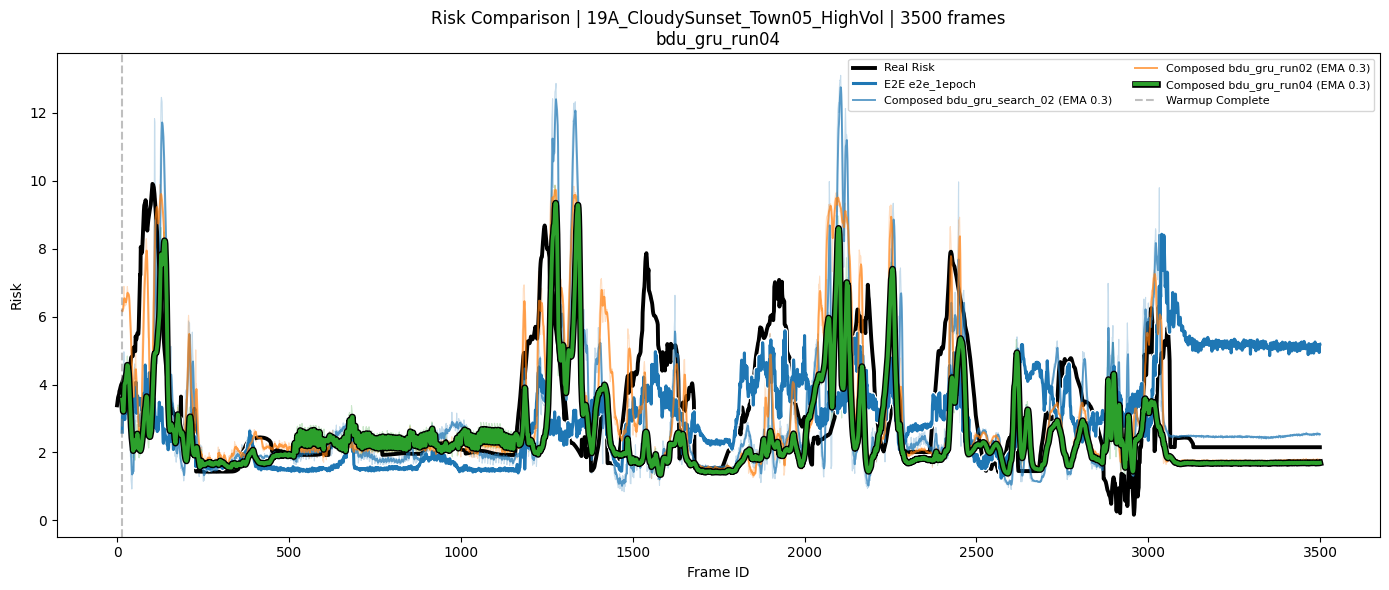

In [25]:
plot_mode = "manual_highlight"  # "manual_highlight", "interactive_selector", "highlight_best", "show_all"
default_checkpoint = "all"
# For plot_mode == "manual_highlight": draws a static (saveable) figure with one
# composed model emphasised. Set to a checkpoint name, an integer index (0..N-1
# over the sorted composed checkpoints), or "all" to emphasise none.
highlight_selection = 1
show_smoothed_composed = True   # plot the EMA-smoothed composed trace instead of the raw one
show_raw_composed_faint = True  # also draw the raw composed trace faintly underneath

_e2e_color_list = ["tab:blue", "tab:cyan", "tab:purple", "tab:olive"]


def _resolve_highlight(selection) -> str:
    """Map a name / integer index / 'all' to a composed checkpoint name."""
    names = sorted(composed_arr_by_model.keys())
    if selection is None or selection == "all":
        return "all"
    if isinstance(selection, int) or (isinstance(selection, str) and selection.lstrip("-").isdigit()):
        i = int(selection)
        if not names:
            return "all"
        if not (0 <= i < len(names)):
            raise IndexError(f"highlight index {i} out of range [0, {len(names) - 1}]")
        return names[i]
    if selection in composed_arr_by_model:
        return selection
    raise KeyError(f"highlight '{selection}' not found. Options: {names}")


def _draw_plot(selected_checkpoint: str = "all") -> None:
    plt.figure(figsize=(14, 6))
    plt.plot(x, real_arr, label="Real Risk", linewidth=2.8, color="black")

    for idx, (name, arr) in enumerate(e2e_arr_by_model.items()):
        color = _e2e_color_list[idx % len(_e2e_color_list)]
        line, = plt.plot(x, arr, label=f"E2E {name}", linewidth=2.2, color=color)
        line.set_path_effects([pe.Stroke(linewidth=4.0, foreground="white"), pe.Normal()])

    cmap = plt.cm.get_cmap("tab10")
    # In manual_highlight, draw every model but emphasise only the selected one;
    # in interactive_selector, hide the non-selected models entirely.
    emphasise_only = plot_mode in {"manual_highlight", "highlight_best"}
    for idx, (name, raw_arr) in enumerate(composed_arr_by_model.items()):
        show = emphasise_only or selected_checkpoint == "all" or selected_checkpoint == name
        if not show:
            continue
        is_em = selected_checkpoint == name or (plot_mode == "highlight_best" and name == best_name)
        lw = 2.8 if is_em else 1.4
        color = cmap(idx % 10)
        pred_arr = composed_smoothed_by_model[name] if show_smoothed_composed else raw_arr
        if show_smoothed_composed and show_raw_composed_faint:
            plt.plot(x, raw_arr, linewidth=0.8, alpha=0.25, color=color, zorder=1)
        label = f"Composed {name}" + (f" (EMA {EMA_ALPHA})" if show_smoothed_composed else "")
        line, = plt.plot(x, pred_arr, label=label, linewidth=lw,
                         alpha=1.0 if is_em else 0.7, color=color, zorder=5 if is_em else 2)
        if is_em:
            line.set_path_effects([pe.Stroke(linewidth=lw + 2.0, foreground="black"), pe.Normal()])

    if len(x) >= Config.INFERENCE_SEQUENCE_LENGTH:
        plt.axvline(x=x[Config.INFERENCE_SEQUENCE_LENGTH - 1], color="gray", linestyle="--", alpha=0.5, label="Warmup Complete")

    plt.xlabel("Frame ID"); plt.ylabel("Risk")
    title = f"Risk Comparison | {selected_scenario_dir.name} | {len(x)} frames"
    if selected_checkpoint != "all":
        title += f"\n{selected_checkpoint}"
    plt.title(title)
    plt.legend(loc="upper right", ncol=2, fontsize=8)
    plt.tight_layout()
    plt.show()


if run_composed and composed_arr_by_model and plot_mode == "manual_highlight":
    _hl = _resolve_highlight(highlight_selection)
    print(f"Highlighting: {_hl}")
    _draw_plot(_hl)
elif run_composed and composed_arr_by_model and plot_mode == "interactive_selector":
    try:
        import ipywidgets as widgets
        from IPython.display import display as ipy_display
        options = ["all"] + sorted(composed_arr_by_model.keys())
        selector = widgets.Dropdown(options=options, value="all", description="Checkpoint:", layout=widgets.Layout(width="320px"))
        ipy_display(widgets.VBox([selector, widgets.interactive_output(_draw_plot, {"selected_checkpoint": selector})]))
    except Exception as exc:
        print(f"Interactive selector unavailable ({exc}). Using static plot.")
        _draw_plot(default_checkpoint)
else:
    _draw_plot(default_checkpoint)

## Town05 Overlay (Sets 17 to 21)
Compare two Town05 scenarios from sets 17 to 21 only, with predicted risk overlaid on top of real risk (Town10 excluded).

In [ ]:
import re

overlay_max_frames = min(500, int(num_frames_to_plot))
overlay_e2e_keys = list(e2e_predictors.keys())
overlay_composed_keys = ["bdu_gru_search_02"]

_slot_re = re.compile(r"^(?P<set>\d{2})(?P<letter>[A-D])_")


def _is_town10(name: str) -> bool:
    return "town10" in name.lower()


def _scenario_crop_bbox(scenario_dir):
    """Read the dashboard crop the composed features were labeled with, from this
    scenario's dataset_labeled.jsonl. Returns None if unavailable (no crop)."""
    labeled = scenario_dir / "dataset_labeled.jsonl"
    if not labeled.is_file():
        return None
    for rec in load_jsonl_records(str(labeled)):
        bbox = rec.get("crop_bbox_xyxy")
        if isinstance(bbox, (list, tuple)) and len(bbox) == 4:
            return [float(v) for v in bbox]
    return None


def _load_scenario_series(scenario_dir, max_frames: int):
    recs = load_jsonl_records(str(scenario_dir / source_jsonl_name))
    paths, real = [], []
    for rec in recs:
        rel = str(rec.get("rgb_image_path", "")).strip()
        if not rel:
            continue
        full = resolve_image_path(str(scenario_dir), rel, normalize_paths=True)
        if not os.path.isfile(full):
            continue
        paths.append(full)
        real.append(float(rec.get("ground_truth_risk", 0.0)))
        if len(paths) >= max_frames:
            break
    if not paths:
        raise RuntimeError(f"No valid frames in {scenario_dir.name}")
    return paths, np.asarray(real, dtype=np.float32)


def _predict_series(predictor, frame_paths: list, tag: str) -> np.ndarray:
    predictor.reset_queue()
    preds = []
    for idx, fp in enumerate(frame_paths, start=1):
        out = predictor.add_image_path(fp)
        preds.append(float(out.latest_risk) if out.ready and out.latest_risk is not None else np.nan)
        if idx % 100 == 0 or idx == len(frame_paths):
            print(f"  [{tag}] {idx}/{len(frame_paths)}")
    return np.asarray(preds, dtype=np.float32)


def _mse(pred: np.ndarray, target: np.ndarray) -> float:
    mask = np.isfinite(pred) & np.isfinite(target)
    return float(np.mean((pred[mask] - target[mask]) ** 2)) if np.any(mask) else float("nan")

## Town10 Overlay — Multi-Scenario Comparison

Runs both models on two Town10 scenarios side by side.

### Helper Functions

### Scenario Discovery + Frame Loading

In [13]:
# Build overlay predictor dict — load any missing composed checkpoints on demand
overlay_predictors = {}
for key in overlay_e2e_keys:
    if key in e2e_predictors:
        overlay_predictors[f"e2e:{key}"] = e2e_predictors[key]
for key in overlay_composed_keys:
    if key not in composed_predictors:
        if key in composed_checkpoint_paths and composed_checkpoint_paths[key].is_file():
            composed_predictors[key] = QueuedComposedBDUGRURiskInference.from_checkpoint(
                checkpoint_path=str(composed_checkpoint_paths[key]),
                feature_integrator=FeatureIntegrator(),
                yolo_model=yolo_model or YOLO(str(MODEL_PATHS["yolo"])),
                depth_estimator=depth_estimator,
                environment_predictor=environment_predictor,
                road_segmentation=road_segmentation,
                device=device_name,
            )
            print(f"Loaded on-demand: {key}")
    if key in composed_predictors:
        overlay_predictors[f"composed:{key}"] = composed_predictors[key]

if not overlay_predictors:
    raise RuntimeError("No overlay predictors available.")

# Pick two Town10 scenarios
town10_candidates = sorted([p for p in scenario_dirs if _is_town10(p.name)], key=lambda p: p.name)
if len(town10_candidates) < 2:
    raise RuntimeError(f"Need ≥2 Town10 scenarios, found: {[p.name for p in town10_candidates]}")

scenario_a = town10_candidates[0]
scenario_b = town10_candidates[-1] if town10_candidates[-1] != town10_candidates[0] else town10_candidates[1]

print(f"Scenario A: {scenario_a.name}")
print(f"Scenario B: {scenario_b.name}")

a_paths, a_real = _load_scenario_series(scenario_a, overlay_max_frames)
b_paths, b_real = _load_scenario_series(scenario_b, overlay_max_frames)
print(f"Loaded {len(a_paths)} / {len(b_paths)} frames from A / B.")

Scenario A: 17C_WetNoon_Town10HD_HighVol
Scenario B: 21D_HardRainNoon_Town10HD_LowVol_NoFog_Night
Loaded 500 / 500 frames from A / B.


### Run Overlay Inference

In [14]:
a_preds_by_model, b_preds_by_model = {}, {}

# Composed predictors are cropped before perception; use the same fixed crop as
# NB_13 ([0, 0, 512, 305]) for every scenario so the overlay matches the trial
# pipeline. Set it (and clear the per-frame caches) before each series.
# E2E predictors ignore the crop.
crop_a = crop_b = [0, 0, 512, 305]
print(f"Crop A: {crop_a}  |  Crop B: {crop_b}")


def _predict_series_with_crop(predictor, frame_paths, tag, crop_bbox):
    if hasattr(predictor, "manual_crop_bbox"):
        predictor.manual_crop_bbox = normalize_crop_bbox_xyxy(crop_bbox)
        predictor.clear_preprocess_cache()
    return _predict_series(predictor, frame_paths, tag)


for model_name, predictor in overlay_predictors.items():
    print(f"\n--- {model_name} ---")
    a_preds_by_model[model_name] = _predict_series_with_crop(predictor, a_paths, f"A:{model_name}", crop_a)
    b_preds_by_model[model_name] = _predict_series_with_crop(predictor, b_paths, f"B:{model_name}", crop_b)

a_mse_by_model = {k: _mse(arr, a_real) for k, arr in a_preds_by_model.items()}
b_mse_by_model = {k: _mse(arr, b_real) for k, arr in b_preds_by_model.items()}

print("\nMSE summary:")
for name in overlay_predictors:
    print(f"  {name}: A={a_mse_by_model[name]:.6f}  B={b_mse_by_model[name]:.6f}")


--- e2e:e2e_latest ---
  [A:e2e:e2e_latest] 100/500
  [A:e2e:e2e_latest] 200/500
  [A:e2e:e2e_latest] 300/500
  [A:e2e:e2e_latest] 400/500
  [A:e2e:e2e_latest] 500/500
  [B:e2e:e2e_latest] 100/500
  [B:e2e:e2e_latest] 200/500
  [B:e2e:e2e_latest] 300/500
  [B:e2e:e2e_latest] 400/500
  [B:e2e:e2e_latest] 500/500

--- e2e:e2e_1epoch ---
  [A:e2e:e2e_1epoch] 100/500
  [A:e2e:e2e_1epoch] 200/500
  [A:e2e:e2e_1epoch] 300/500
  [A:e2e:e2e_1epoch] 400/500
  [A:e2e:e2e_1epoch] 500/500
  [B:e2e:e2e_1epoch] 100/500
  [B:e2e:e2e_1epoch] 200/500
  [B:e2e:e2e_1epoch] 300/500
  [B:e2e:e2e_1epoch] 400/500
  [B:e2e:e2e_1epoch] 500/500

--- composed:bdu_gru_search_02 ---
  [A:composed:bdu_gru_search_02] 100/500
  [A:composed:bdu_gru_search_02] 200/500
  [A:composed:bdu_gru_search_02] 300/500
  [A:composed:bdu_gru_search_02] 400/500
  [A:composed:bdu_gru_search_02] 500/500
  [B:composed:bdu_gru_search_02] 100/500
  [B:composed:bdu_gru_search_02] 200/500
  [B:composed:bdu_gru_search_02] 300/500
  [B:com

### Interactive Side-by-Side Plot

In [15]:
_e2e_colors = ["tab:blue", "tab:cyan", "tab:purple", "tab:olive"]
_comp_colors = ["tab:orange", "tab:red", "tab:pink", "tab:brown"]
_overlay_colors = {}
_ei = _ci = 0
for name in overlay_predictors:
    if name.startswith("e2e:"):
        _overlay_colors[name] = _e2e_colors[_ei % len(_e2e_colors)]; _ei += 1
    else:
        _overlay_colors[name] = _comp_colors[_ci % len(_comp_colors)]; _ci += 1


def _draw_overlay(selected_model: str = "all") -> None:
    fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

    for ax, real, preds_by_model, mse_by_model, scen_dir in [
        (ax_a, a_real, a_preds_by_model, a_mse_by_model, scenario_a),
        (ax_b, b_real, b_preds_by_model, b_mse_by_model, scenario_b),
    ]:
        x_ov = np.arange(len(real), dtype=np.int64)
        ax.plot(x_ov, real, label="Real Risk", linewidth=2.2, color="black")
        for name, arr in preds_by_model.items():
            if selected_model != "all" and selected_model != name:
                continue
            is_em = selected_model == name
            lw = 2.4 if is_em else 1.4
            line, = ax.plot(x_ov, arr,
                            label=f"{name} (MSE={mse_by_model.get(name, float('nan')):.5f})",
                            linewidth=lw, color=_overlay_colors.get(name, "gray"),
                            alpha=1.0 if is_em else 0.65, zorder=5 if is_em else 2)
            if is_em:
                line.set_path_effects([pe.Stroke(linewidth=lw + 2.0, foreground="black"), pe.Normal()])
        ax.set_xlabel("Frame Index"); ax.set_ylabel("Risk")
        ax.set_title(scen_dir.name)
        ax.legend(fontsize=7, loc="upper right")

    suffix = f" — {selected_model}" if selected_model != "all" else ""
    plt.suptitle(f"Town10 Risk Overlay{suffix}", fontsize=12)
    plt.tight_layout()
    plt.show()


try:
    import ipywidgets as widgets
    from IPython.display import display as ipy_display
    model_options = ["all"] + list(overlay_predictors.keys())
    selector = widgets.Dropdown(options=model_options, value="all", description="Model:", layout=widgets.Layout(width="360px"))
    ipy_display(widgets.VBox([selector, widgets.interactive_output(_draw_overlay, {"selected_model": selector})]))
except Exception as exc:
    print(f"Interactive selector unavailable ({exc}). Using static plot.")
    _draw_overlay("all")